In [1]:
from google.colab import files

print("Upload your CSV files:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"✅ {filename} uploaded!")

Upload your CSV files:


Saving test_data.csv to test_data.csv
Saving train_data.csv to train_data.csv
✅ test_data.csv uploaded!
✅ train_data.csv uploaded!


The previous cell handles the file upload process. It uses `google.colab.files` to prompt the user to upload CSV files, which are necessary for training and testing the forecasting model. The output confirms that `test_data.csv` and `train_data.csv` were successfully uploaded, indicating the data is now available in the Colab environment.

In [2]:
!pip install prophet -q

print("✅ Prophet installed successfully!")

✅ Prophet installed successfully!


The previous cell successfully installed the `prophet` library, which is Facebook's open-source forecasting tool. This library is crucial for building time-series models.

## STEP 3: Load Data & Prepare for Prophet

In [3]:
import pandas as pd
from prophet import Prophet

# Load the training data
train_df = pd.read_csv('train_data.csv')

# Prepare the training data for Prophet
# Prophet requires columns 'ds' (datestamp) and 'y' (target variable)
train_df = train_df[['date', 'total_sales']]
train_df = train_df.rename(columns={'date': 'ds', 'total_sales': 'y'})
train_df['ds'] = pd.to_datetime(train_df['ds'])

print("Training data loaded and prepared:")
display(train_df.head())

# Load the test data (for future forecasting if needed)
test_df = pd.read_csv('test_data.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
print("\nTest data loaded:")
display(test_df.head())

Training data loaded and prepared:


,ds,y
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146



Test data loaded:


,d,total_sales,date,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,...,rolling_mean_7,rolling_mean_14,rolling_mean_30,month_sin,month_cos,day_sin,day_cos,avg_price,price_lag_7,price_change
0,d_1340,31473,2014-09-29,9,2014,NaN,NaN,0,0,0,...,33755.000000,34270.714286,36587.800000,-1.000000,-1.836970e-16,-0.999546,-0.030120,4.447986,4.447541,0.0
1,d_1341,29990,2014-09-30,9,2014,NaN,NaN,0,0,0,...,33837.857143,34195.928571,36280.466667,-1.000000,-1.836970e-16,-0.999917,-0.012910,4.447986,4.447541,0.0
2,d_1342,34602,2014-10-01,10,2014,NaN,NaN,1,1,0,...,34638.000000,34536.714286,35992.000000,-0.866025,5.000000e-01,-0.999991,0.004304,4.447986,4.447541,0.0
3,d_1343,34249,2014-10-02,10,2014,NaN,NaN,1,0,1,...,35314.857143,34921.571429,35990.333333,-0.866025,5.000000e-01,-0.999769,0.021516,4.447986,4.447541,0.0
4,d_1344,41836,2014-10-03,10,2014,NaN,NaN,1,1,1,...,36559.000000,35421.857143,36138.300000,-0.866025,5.000000e-01,-0.999250,0.038722,4.447986,4.447541,0.0


The previous cell performed the crucial step of loading the `train_data.csv` and `test_data.csv` files into pandas DataFrames. It then prepared the training data specifically for Prophet by renaming the 'date' column to 'ds' (datestamp) and 'total_sales' to 'y' (target variable), and converted the 'ds' column to datetime objects. The `head()` display shows the first few rows of both the prepared training data and the raw test data, confirming the successful load and initial transformation.

## STEP 4: Train the Prophet Model

In [4]:
# Initialize and fit the Prophet model
# You can add parameters like daily_seasonality, weekly_seasonality, etc. here
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
model.fit(train_df)

print("Prophet model trained successfully!")

Prophet model trained successfully!


This cell initializes and trains the Prophet model using the prepared `train_df`. Parameters like `daily_seasonality`, `weekly_seasonality`, and `yearly_seasonality` are set to `True` to allow the model to capture these patterns in the sales data. The output confirms that the model has been successfully trained on the provided historical sales data, and it is now ready to make predictions.

## STEP 5: Make Future Predictions

In [5]:
# Create a DataFrame with future dates for forecasting
# We'll use the 'date' column from the test_df for future predictions
future = pd.DataFrame({'ds': test_df['date']})

# Make predictions
forecast = model.predict(future)

print("Forecast generated:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Forecast generated:


,ds,yhat,yhat_lower,yhat_upper
0,2014-09-29,35248.524944,31022.449779,39459.311033
1,2014-09-30,32854.097437,28421.537259,36963.336266
2,2014-10-01,32339.259008,28173.194994,36744.311695
3,2014-10-02,32688.067173,28712.893135,37065.198150
4,2014-10-03,36595.425644,32159.752491,40881.572536


The previous cell generated a `future` DataFrame containing the dates from the `test_df`. It then used the trained Prophet model to make predictions (`forecast`) for these future dates. The output displays the first few rows of the forecast, showing the predicted sales (`yhat`) along with their lower (`yhat_lower`) and upper (`yhat_upper`) confidence intervals. This gives us a preliminary view of the forecasted sales for the test period.

## STEP 6: Visualize the Forecast

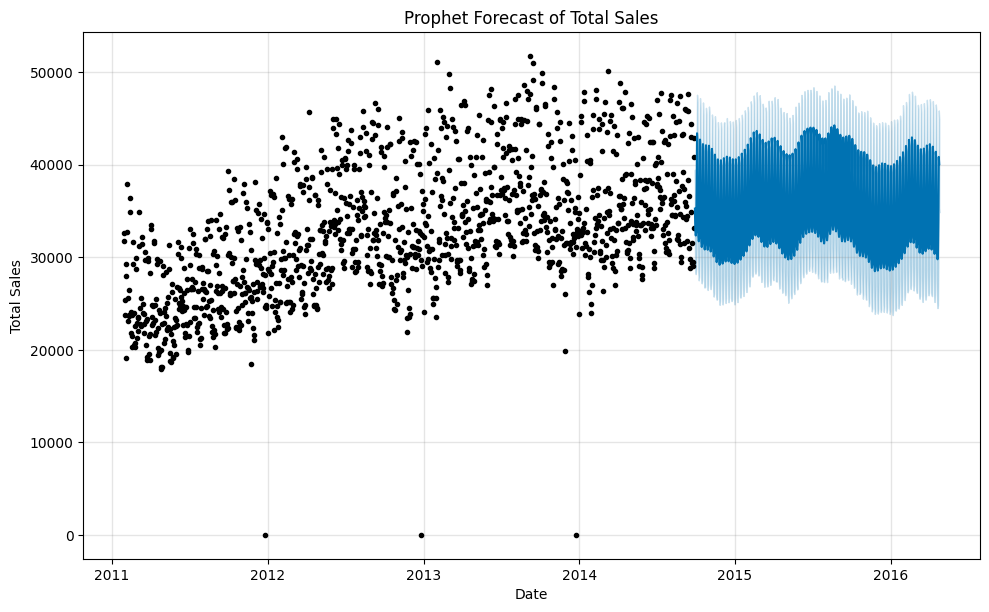

In [6]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.title('Prophet Forecast of Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

The previous cell visualizes the Prophet forecast. The plot displays the historical data (black dots), the model's fitted trend (blue line), and the forecasted values with their uncertainty intervals (light blue shaded area). This visualization provides a clear overview of how well the model fits the past data and its predictions for future sales trends. It's a key step to visually inspect the forecast quality.

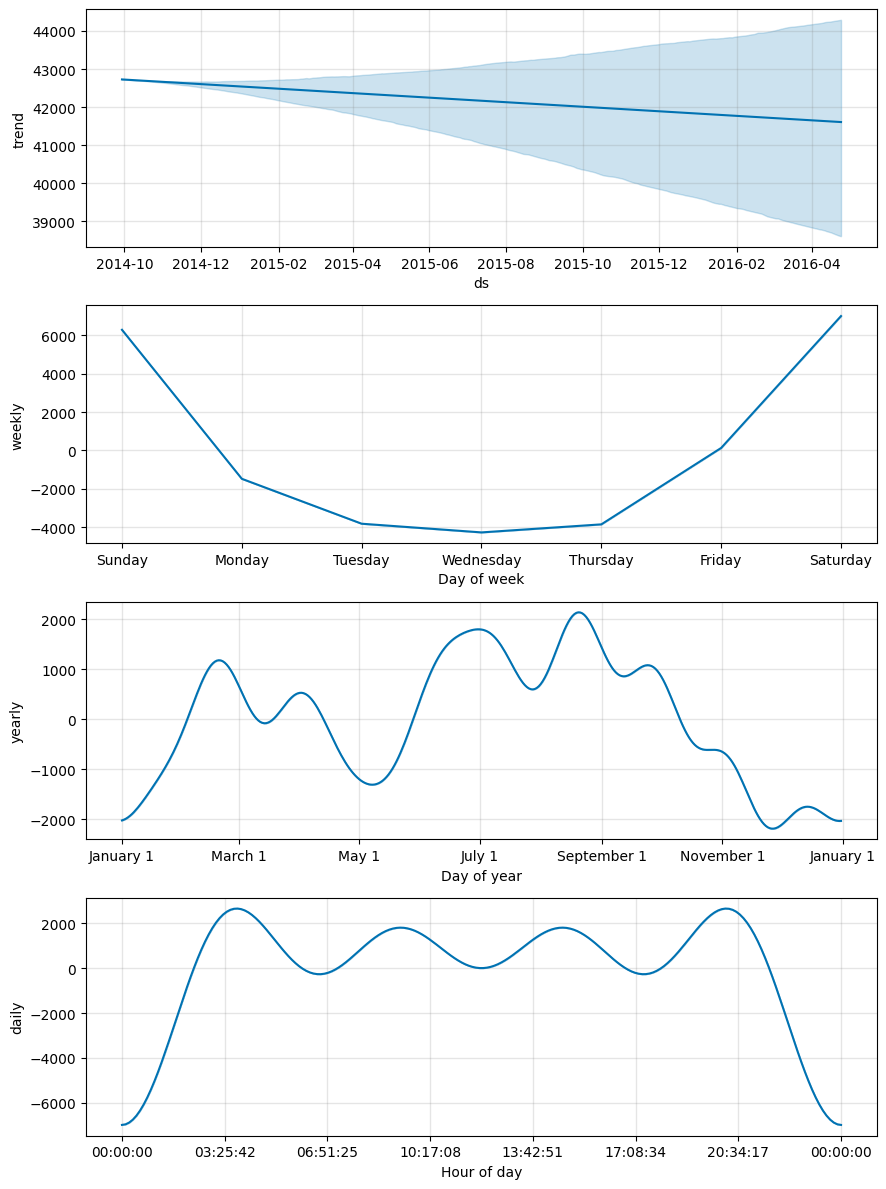

In [7]:
# Plot the components of the forecast
fig2 = model.plot_components(forecast)
plt.show()

The previous cell generated plots showing the individual components of the forecast: trend, weekly seasonality, daily seasonality, and yearly seasonality (if enabled). These plots help to understand the underlying patterns and contributions to the overall sales forecast. For instance, the weekly seasonality plot might reveal higher sales on specific days of the week, and the daily seasonality plot could show variations within a 24-hour cycle. This decomposition is valuable for gaining deeper insights into the sales dynamics.

In [8]:
# Save forecast CSV
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_output.to_csv('forecast_output.csv', index=False)

print("✅ Ready to download!")

✅ Ready to download!
